# AML Football Evaluation Notebook (Laliga)

#### This notebook contains evaluation results of Laliga model goals prediction. The aim is to understand what the machine learning model focuses on to make prediction and evaluate it accuracy in doing so.

#### We made sure the same hyperparameters that was used in this evaluation results were used in the production model.

#### evaluation was carried out on the last ten percent of total matches played by each team on the dataset.

#### Training and model achitecture technique on the model will remain private.

In [48]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
import matplotlib.pyplot as plt

In [49]:
laliga = pd.read_csv("laliga_eval.csv")

In [50]:
laliga.head()

,Team,Opponent,IsHome,GoalsFor,GoalsAgainst,Pred_HomeGoals,Pred_AwayGoals
0,Alaves,Elche,1,3,1,2.043217,1.096217
1,Alaves,Valencia,1,0,0,1.814811,1.601273
2,Alaves,Vallecano,0,0,1,0.254441,2.268423
3,Alaves,Espanol,1,2,1,1.966782,1.831511
4,Alaves,Girona,0,0,1,2.420717,2.541351


In [51]:
valid = laliga.dropna(subset=["Pred_HomeGoals", "Pred_AwayGoals"])

# Compute MAE
home_mae = mean_absolute_error(valid["GoalsFor"], valid["Pred_HomeGoals"])
away_mae = mean_absolute_error(valid["GoalsAgainst"], valid["Pred_AwayGoals"])

# Compute RMSE
home_rmse = np.sqrt(mean_squared_error(valid["GoalsFor"], valid["Pred_HomeGoals"]))
away_rmse = np.sqrt(mean_squared_error(valid["GoalsAgainst"], valid["Pred_AwayGoals"]))

# Print neatly
print("Model Evaluation Metrics (per match):")
print("-------------------------------------")
print(f"Home Goals -> MAE: {home_mae:.2f}, RMSE: {home_rmse:.2f}")
print(f"Away Goals -> MAE: {away_mae:.2f}, RMSE: {away_rmse:.2f}")
print("\nNotes:")
print("- MAE shows the typical error per match (average goals off).")
print("- RMSE shows typical error magnitude, giving more weight to larger mistakes or model prediction error.")

Model Evaluation Metrics (per match):
-------------------------------------
Home Goals -> MAE: 0.96, RMSE: 1.20
Away Goals -> MAE: 0.99, RMSE: 1.33

Notes:
- MAE shows the typical error per match (average goals off).
- RMSE shows typical error magnitude, giving more weight to larger mistakes or model prediction error.


In [52]:
laliga.rename(columns={"Pred_HomeGoals": "RawPred_Home"}, inplace=True)
laliga.rename(columns={"Pred_AwayGoals": "RawPred_Away"}, inplace=True)

In [53]:
laliga["Pred_home"] = laliga["RawPred_Home"].round().astype(int)
laliga["Pred_away"] = laliga["RawPred_Away"].round().astype(int)

In [54]:
laliga["Actual_Outcome"] = np.where(laliga["GoalsFor"] > laliga["GoalsAgainst"], "W",
                                    np.where(laliga["GoalsFor"] < laliga["GoalsAgainst"], "L", "D"))

laliga["Predicted_Outcome"] = np.where(laliga["Pred_home"] > laliga["Pred_away"], "W",
                                    np.where(laliga["Pred_home"] < laliga["Pred_away"], "L", "D"))

In [55]:
accuracy = accuracy_score(laliga["Actual_Outcome"], laliga["Predicted_Outcome"])
accuracy

0.42395437262357416

In [56]:
clss_report = classification_report(laliga["Actual_Outcome"].values, laliga["Predicted_Outcome"].values)
print(clss_report)

              precision    recall  f1-score   support

           D       0.23      0.31      0.27       120
           L       0.66      0.32      0.43       213
           W       0.44      0.61      0.51       193

    accuracy                           0.42       526
   macro avg       0.45      0.41      0.40       526
weighted avg       0.48      0.42      0.42       526



In [57]:
laliga["Home_Error"] = laliga["GoalsFor"] - laliga["Pred_home"]
laliga["Away_Error"] = laliga["GoalsAgainst"] - laliga["Pred_away"]

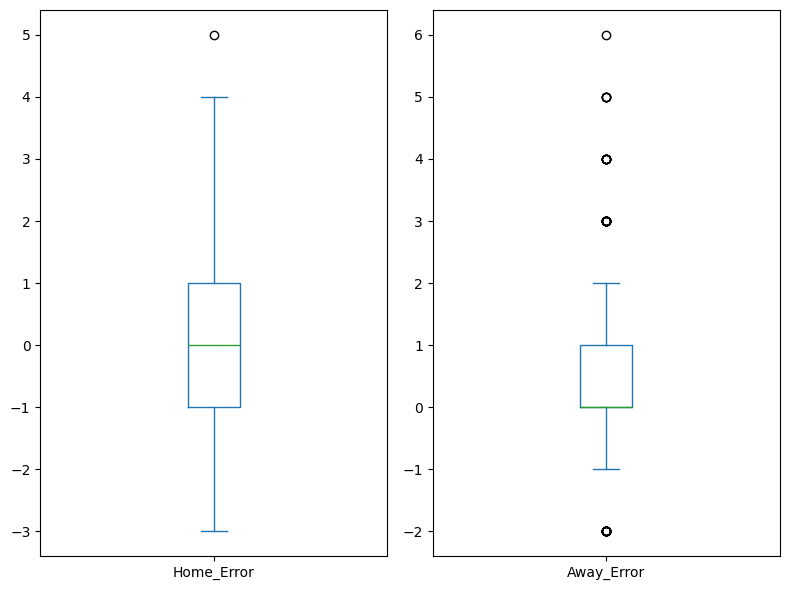

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6))

laliga["Home_Error"].plot.box(vert=True, ax=axes[0])
laliga["Away_Error"].plot.box(vert=True, ax=axes[1])

plt.tight_layout()
plt.show()

In [59]:
laliga["Home_Error"].value_counts()

Home_Error
 0    161
-1    149
 1    109
-2     50
 2     38
 3     10
-3      6
 4      2
 5      1
Name: count, dtype: int64

In [60]:
laliga["Away_Error"].value_counts()

Away_Error
 0    175
 1    134
-1    100
 2     65
-2     20
 3     20
 4      7
 5      4
 6      1
Name: count, dtype: int64

In [61]:
count = laliga["Home_Error"].isin([0, 1, -1]).sum()
print(count/len(laliga))

0.7965779467680608


In [62]:
count = laliga["Away_Error"].isin([0, 1, -1]).sum()
print(count/len(laliga))

0.7775665399239544


In [63]:
laliga["Team"].value_counts()

Team
Ath Bilbao     26
Ath Madrid     26
Barcelona      26
Betis          26
Celta          26
Getafe         26
Osasuna        26
Real Madrid    26
Sevilla        26
Sociedad       26
Valencia       26
Villarreal     26
Alaves         22
Cadiz          19
Elche          19
Mallorca       19
Vallecano      19
Granada        16
Valladolid     16
Espanol        15
Girona         15
Levante        15
Almeria         8
Eibar           8
Huesca          8
Las Palmas      8
Leganes         4
Oviedo          3
Name: count, dtype: int64

In [93]:
def ext_mode(df):
    """
    This code extract the maximum value the model have been wrong by for the team
    """
    maxi = {}

    for team, group in df.groupby("Team"):
        max_value = group["Home_Error"].max()
        maxi[team] = max_value
        
    return maxi

In [94]:
maxi = ext_mode(laliga)

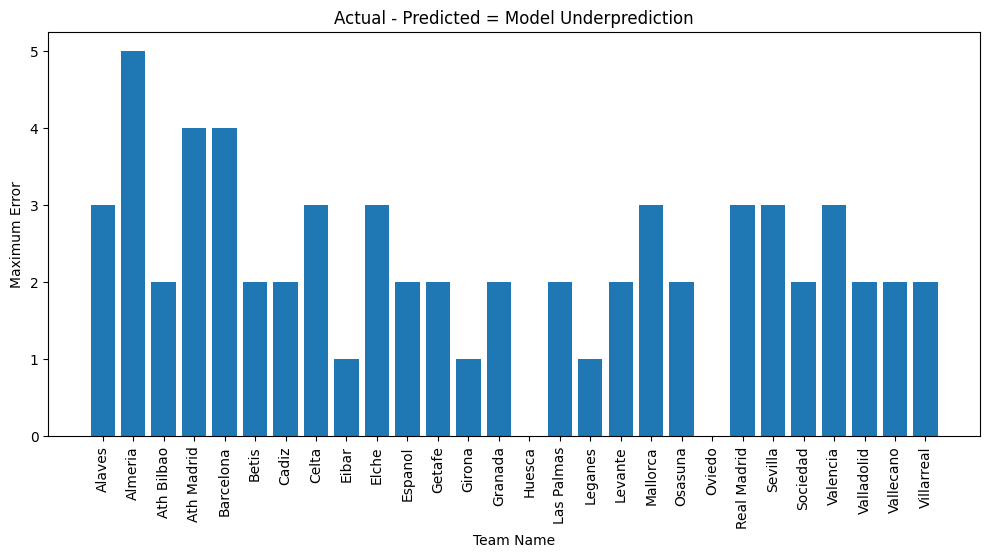

In [102]:
plt.figure(figsize=(10, 5))
plt.bar(maxi.keys(), maxi.values())
plt.xlabel("Team Name")
plt.ylabel("Maximum Error")
plt.title("Actual - Predicted = Model Underprediction")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [100]:
#Checking patterns of teams that performed more than expected have in similar based on the plots above 3, 4 and 5

outliers = laliga[laliga["Home_Error"].isin([3, 4, 5, 6])]
outliers

,Team,Opponent,IsHome,GoalsFor,GoalsAgainst,RawPred_Home,RawPred_Away,Pred_home,Pred_away,Actual_Outcome,Predicted_Outcome,Home_Error,Away_Error
21,Alaves,Celta,0,4,3,1.402176,1.264135,1,1,W,D,3,2
29,Almeria,Cadiz,1,6,1,0.866106,0.695758,1,1,W,D,5,0
59,Ath Madrid,Real Madrid,1,5,2,1.030837,1.410489,1,1,W,D,4,1
64,Ath Madrid,Levante,1,3,1,0.471292,0.602666,0,1,W,L,3,0
82,Barcelona,Valencia,1,6,0,1.547635,0.585858,2,1,W,W,4,-1
94,Barcelona,Betis,0,5,3,1.812507,1.625365,2,2,W,D,3,1
167,Celta,Valencia,1,4,1,1.482614,1.303595,1,1,W,D,3,0
193,Elche,Vallecano,1,4,0,1.026325,0.508428,1,1,W,D,3,-1
324,Mallorca,Sevilla,1,4,1,1.246112,0.890997,1,1,W,D,3,0
376,Real Madrid,Betis,1,5,1,1.918871,0.345393,2,0,W,W,3,1


In [101]:
outliers["IsHome"].value_counts()

IsHome
1    11
0     2
Name: count, dtype: int64

## There is a clear pattern that when a team is home, There is a little chance it can perform more than predicted often extremely from 3 to 5 goals model underprediction. The away team in this outliers have just 3 goals model underprediction which is still manageable

# SUMMARY

## The model performs badly in 3 way scenerio (i.e home/draw/away) having 42% accuracy which isnt reliable, but performs very good in recognizing possible goals that can be scored, taking into consideration; exact goal +1, and -1 goals scenerio, with an average accuracy of 79%.

## Outliers events are 4, 5 and 6 goals underprediction. In order to put it out to production, we will focus on managing the risks associated with these errors.
## Further evaluation showed ingame red cards is a big factor for model overprediction i.e where actual goals scored is less than predicted goals